# Try MCMC with only 4 params, fixed R and fixed rotational broadening

In [1]:
import os
import sys
import math
import numpy as np
import matplotlib.pyplot as plt
import scipy
import scipy.stats as sps
from scipy.optimize import minimize
import schwimmbad
import PyPDF2
import tensorflow as tf
import keras
from keras.models import load_model
import json
import pandas as pd
import corner
import emcee
import PyAstronomy.pyasl as pyasl
from astropy.io import fits
#%matplotlib widget

In [2]:
# Load BLOeM spectrum
fits_path = "/Users/hulya/Desktop/Alles/UvA/MSc_project/BLOeM_4-074_Coadded.fits"
fit = fits.open(fits_path)
data = fit[1].data

# Extract wavelength and flux from BLOeM
bloem_wl = data["WAVELENGTH"]   # Angstrom

In [ ]:
#import Anja's model for inference
model = keras.saving.load_model('NN_model.keras')

# Load the normalization values
with open('normalisation.json') as f:
    norm = json.load(f)

#import the wavelength array for the predictions, sort it and build an evenly spaced grid for interpolation and adding rotational broadening
df = pd.read_csv('wavelengths.csv')
master_wl=df['master wl Halpha_HeII6527 combined model 19002']
master_wl = np.asarray(master_wl)
order = np.argsort(master_wl) # sort the wavelength array and get the corresponding indices to apply to the flux array
master_wl = master_wl[order]
master_wl_unique, unique_idx = np.unique(master_wl, return_index=True) # remove duplicates
wl_min = master_wl_unique.min()
wl_max = master_wl_unique.max()
uniform_step = 0.2 # Use BLOeM resolution scale (~0.2 Å)
wl_uniform = np.arange(wl_min, wl_max, uniform_step)

PARAM_NAMES = ['teff', 'logg', 'logmdot', 'yhe']
LABELS = ['Teff', 'logg', 'logmdot', 'YHe'] 

def normalize(col_name, unnormalized_val):
    mn = norm[f'{col_name}_min']
    mx = norm[f'{col_name}_max']
    return (unnormalized_val - mn) / (mx - mn)

def normalize_theta(theta):
    return np.array([normalize('teff', theta[0]),normalize('logg', theta[1]),normalize('radius', theta[2]),normalize('logmdot', theta[3]),normalize('yhe', theta[4])])

def add_noise(prediction, snr):
    '''add Gaussian noise to the prediction and plot again'''
    sigma = 1/snr
    noisy_flux = prediction + np.random.normal(0.0, sigma, size=prediction.shape)
    return noisy_flux

def simulate_model_spectrum(theta_full, model, vsini=None, epsilon=None, output_wl=None):
    norm_params = normalize_theta(theta_full) # normalize the input parameters to the [0,1] range expected by the model
    flux_master = model(norm_params[None, :], training=False).numpy().ravel() 
    flux_master = flux_master[order] # reorder + deduplicate
    flux_unique = flux_master[unique_idx] # flux_master is now on the master_wl_unique grid
    flux_out = np.interp(wl_uniform,master_wl_unique,flux_unique) # interpolate master → uniform grid
    if vsini is not None:
        flux_out = pyasl.rotBroad(wl_uniform,flux_out,epsilon=epsilon,vsini=vsini) # rotational broadening
    if output_wl is not None:
        flux_out=np.interp(output_wl,wl_uniform,flux_out) # interpolate master → output grid
    return flux_out

def log_prior(theta_free):
    """
    theta_free: parameters [teff, logg, logmdot, yhe]
    """
    teff, logg, logmdot, yhe = theta_free
    if not (29000 <= teff <= 52000 and 3.4 <= logg <= 4.3 and -7.5 <= logmdot <= -5.2 and 0.08 <= yhe <= 0.15):
        return -np.inf
    return 0.0

def expand_theta(theta_free, radius_fixed):
    """
    theta_free = [teff, logg, logmdot, yhe]
    returns full theta = [teff, logg, radius, logmdot, yhe]
    """
    return np.array([theta_free[0],theta_free[1],radius_fixed,theta_free[2],theta_free[3]])

def make_log_posterior_fixed_radius(model,observed_wavelength,observed_flux,snr,radius_fixed,vsini=None,epsilon=None):
    sigma = 1.0 / snr

    def log_prior_free(theta_free):
        teff, logg, logmdot, yhe = theta_free
        radius = radius_fixed # radius fixed
        if not (29000 <= teff <= 52000 and 3.4 <= logg <= 4.3 and 6 <= radius <= 21 and -7.5 <= logmdot <= -5.2 and 0.08 <= yhe <= 0.15):
            return -np.inf
        return 0.0

    def log_likelihood_free(theta_free):
        theta_full = expand_theta(theta_free, radius_fixed) # rebuild full theta vector
        sim_flux = simulate_model_spectrum(theta_full, model, vsini=vsini, epsilon=epsilon, output_wl=observed_wavelength) # Simulate the model spectrum with noise and optional rotational broadening
        valid = ~np.isnan(sim_flux) # Only consider points where interpolation was valid (within the model's wavelength range)
        if not np.any(valid):
            return -np.inf

        residual = observed_flux[valid] - sim_flux[valid]
        ll = -0.5 * np.sum((residual / sigma) ** 2)

        return ll if np.isfinite(ll) else -np.inf

    def log_posterior_free(theta_free):
        print("Evaluating log-posterior at theta_free:", theta_free)  # Debug print
        lp = log_prior_free(theta_free)
        if not np.isfinite(lp):
            return -np.inf
        return lp + log_likelihood_free(theta_free)

    return log_posterior_free

def run_mcmc_fixed_radius(observed_flux,observed_wavelength,snr,first_guess_free,model,radius_fixed,
                          vsini=None,epsilon=None,ndim=4,nwalkers,nsteps,thin=10,theta_true = None):
    
    log_posterior = make_log_posterior_fixed_radius(model=model,observed_wavelength=observed_wavelength,observed_flux=observed_flux,
                                                    snr=snr,radius_fixed=radius_fixed,vsini=vsini,epsilon=epsilon) # Create log-posterior function with radius fixed

    res = minimize(lambda t: -log_posterior(t), first_guess_free, method="Nelder-Mead") # Find the MAP estimate starting from the initial guess
    theta_map = res.x # Extract the free parameters from the MAP estimate (the fixed radius is known and not part of the MCMC sampling)
    scale = np.array([500, 0.05, 0.1, 0.005])
    pos = theta_map + scale * np.random.randn(nwalkers, ndim) # Initialize walkers around the MAP estimate
    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior) # Set up the MCMC sampler
    sampler.run_mcmc(pos, nsteps, progress=False) # Run the MCMC sampler
    chain = sampler.chain # Extract the MCMC chain
    tau = sampler.get_autocorr_time(tol=0) # Estimate the autocorrelation time to determine how many steps to discard for burn-in
    discard = 3 * int(np.max(tau)) # Discard 3 times the maximum autocorrelation time as burn-in
    flat_samples = sampler.get_chain(discard=discard, thin=thin, flat=True) # Flatten the chain after discarding burn-in and applying thinning
    theta_50p = np.percentile(flat_samples, 50, axis=0) # Compute the median of the posterior samples for each parameter

    return {
        "observed_flux": observed_flux,
        "observed_wavelength": observed_wavelength,
        "snr": snr,
        "first_guess": first_guess_free,
        "chain": chain,
        "flat_samples": flat_samples,
        "theta_map": theta_map,
        "theta_50p": theta_50p,
        "discard": discard,
        "radius_fixed": radius_fixed,
        "theta_true": theta_true,
    }

def save_results(results, filename):
    np.savez(
        filename,
        observed_flux=results["observed_flux"],
        observed_wavelength=results["observed_wavelength"],
        snr=results["snr"],
        first_guess=results["first_guess"],
        flat_samples=results["flat_samples"],
        theta_map=results["theta_map"],
        chain=results["chain"],
        theta_true=results["theta_true"] if "theta_true" in results else None,
        theta_50p=results["theta_50p"],
        discard=results["discard"],
        radius_fixed=results["radius_fixed"],
    )

def load_results(filename):
    data = np.load(filename, allow_pickle=True)
    return {
        "observed_flux": data["observed_flux"],
        "observed_wavelength": data["observed_wavelength"],
        "snr": data["snr"],
        "first_guess": data["first_guess"],
        "flat_samples": data["flat_samples"],
        "theta_map": data["theta_map"],
        "chain": data["chain"],
        "discard": data["discard"],
        "theta_50p": data["theta_50p"],
        "radius_fixed": data["radius_fixed"],
        "theta_true": data["theta_true"] if "theta_true" in data else None,
    }

def print_posterior_summary(flat_samples):
    print("Median and 1σ uncertainties:")
    for i, label in enumerate(LABELS):
        p16, p50, p84 = np.percentile(flat_samples[:, i], [15.85, 50, 84.15]) # 16th, 50th, and 84th percentiles correspond to median and ±1σ for a Gaussian distribution
        print(f"{label} = {p50:.3f} -{p50-p16:.3f}/+{p84-p50:.3f}")

def plot_corner(flat_samples, truths=None):
    if truths is not None:
        corner.corner(flat_samples,labels=LABELS, truths=truths)
    else:
        corner.corner(flat_samples,labels=LABELS)
    plt.show()

def plot_chains(chain, ndim, discard, truths=None):
    fig, axes = plt.subplots(ndim, 1, figsize=(10, 10), sharex=True)
    for i in range(ndim):
        axes[i].plot(chain[:, :, i].T, alpha=0.3, color='black')
        axes[i].axvline(discard, color='blue', linestyle='--', label='Discarded steps')
        if truths is not None:
            axes[i].axhline(truths[i], color='red', linestyle='-', label='True value')
        axes[i].set_ylabel(LABELS[i])
        axes[i].legend()
    axes[-1].set_xlabel("Step")
    plt.show()

def plot_posterior_predictive(results,observed_flux,observed_wavelength,model,snr,vsini=None, epsilon=None, draw=True, n_draw=100):
    flat_samples = results["flat_samples"]
    theta_50p = results["theta_50p"]

    plt.figure(figsize=(15, 6))
    if draw:
        idx = np.random.choice(len(flat_samples), n_draw, replace=False) # Randomly select n_draw samples from the posterior without replacement
        draw_samples = flat_samples[idx] # Extract the selected samples for plotting
        for i, theta in enumerate(draw_samples):
            sample_theta_full = expand_theta(theta, radius_fixed=results["radius_fixed"]) # Reconstruct the full theta vector for this sample, including the fixed radius
            sample_flux = simulate_model_spectrum(sample_theta_full, model, vsini=vsini, epsilon=epsilon, output_wl=observed_wavelength) # Simulate the spectrum for this sample with noise and optional rotational broadening
            sample_flux = add_noise(sample_flux, snr) # Add noise to the simulated spectrum based on the specified SNR
            plt.plot(observed_wavelength,sample_flux,color='tab:blue',alpha=0.25,linewidth=1,label=f"Posterior Predictive {n_draw} samples" if i == 0 else None)

    theta_50p_full = expand_theta(theta_50p, radius_fixed=results["radius_fixed"]) # Reconstruct the full theta vector for the 50th percentile (median) of the posterior samples, including the fixed radius
    sim_50p_flux = simulate_model_spectrum(theta_50p_full, model, vsini=vsini, epsilon=epsilon, output_wl=observed_wavelength) # Simulate the 50th percentile theta spectrum with noise and optional rotational broadening
    sim_50p_flux = add_noise(sim_50p_flux, snr) # Add noise to the 50th percentile spectrum based on the specified SNR
    interp_sim_50p_flux = np.interp(observed_wavelength, observed_wavelength, sim_50p_flux, left=np.nan, right=np.nan) # Interpolate the 50th percentile theta spectrum onto the observed wavelengths, using NaN for out-of-bounds to avoid extrapolation
    plt.plot(observed_wavelength, observed_flux, color='black', label='Observed spectrum', lw=1)
    plt.plot(observed_wavelength, interp_sim_50p_flux, color='orange', alpha=0.8, lw=1, label='Median posterior predictive')
    plt.xlabel("Wavelength (Å)")
    plt.ylabel("Normalized Flux")
    plt.legend()
    plt.show()

/opt/miniconda3/envs/nn_env/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 18 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


# Run MCMC with simulated data on BLOeM wavelength grid with 4 free parameters

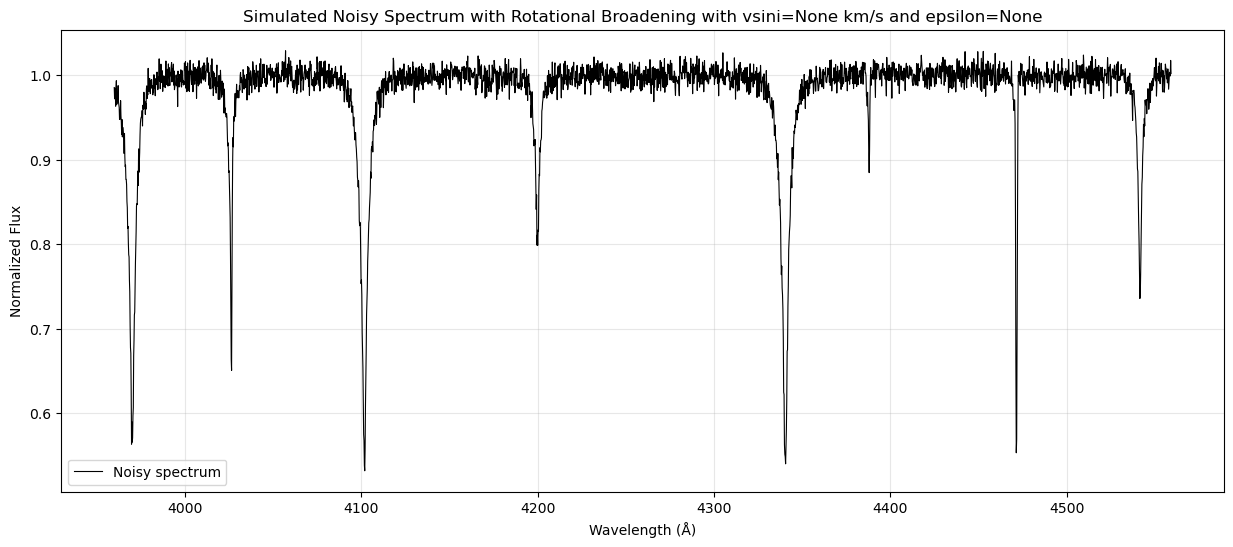

In [4]:
theta_true = [40000, 4.0, -7.0, 0.1]
radius_fixed = 8.0
theta_true_full = expand_theta(theta_true, radius_fixed)
vsini = None
epsilon = None
observed_flux = simulate_model_spectrum(theta_true_full,model=model,vsini=vsini,epsilon=epsilon,output_wl=bloem_wl)
observed_flux = add_noise(observed_flux, snr=100)

plt.figure(figsize=(15, 6))
plt.plot(bloem_wl, observed_flux, color='black', label='Noisy spectrum', lw=0.8)
plt.xlabel("Wavelength (Å)")
plt.ylabel("Normalized Flux")
plt.title(f"Simulated Noisy Spectrum with Rotational Broadening with vsini={vsini} km/s and epsilon={epsilon}")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [6]:
theta_guess = [40000, 4, -7, 0.1]

results = run_mcmc_fixed_radius(
    observed_flux=observed_flux, 
    observed_wavelength=bloem_wl, 
    snr=100,
    first_guess_free=theta_guess,
    model=model,
    radius_fixed=radius_fixed,
    vsini=vsini,
    epsilon=epsilon,
    theta_true=theta_true,
    )

#save_results(results, "mcmc_results_fixed_R_without_rot_broad.npz")

true: [40000, 4.0, -7.0, 0.1]
MAP: [ 4.00304305e+04  4.00811675e+00 -6.92953694e+00  1.01422112e-01]
Median and 1σ uncertainties:
Teff = 40029.525 -98.938/+97.699
logg = 4.009 -0.009/+0.009
logmdot = -6.945 -0.133/+0.112
YHe = 0.102 -0.002/+0.002


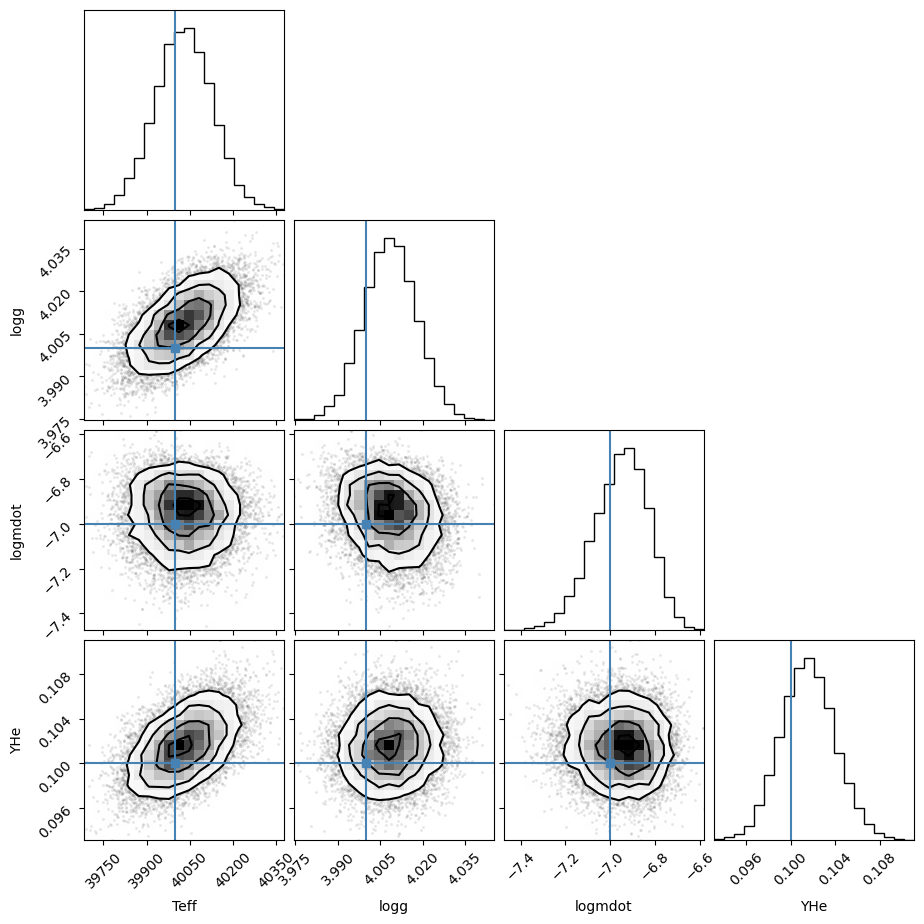

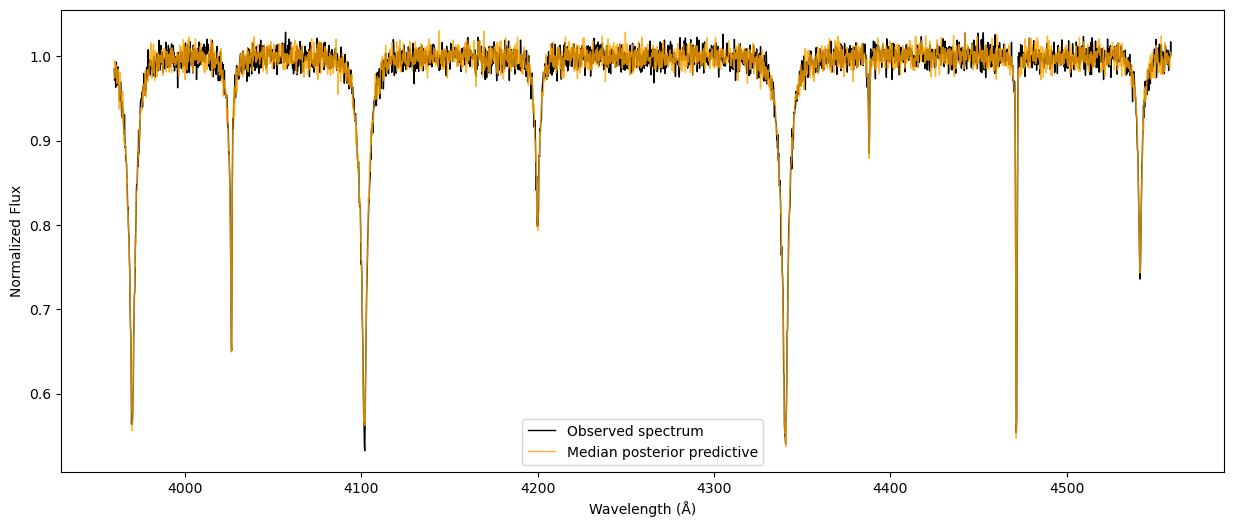

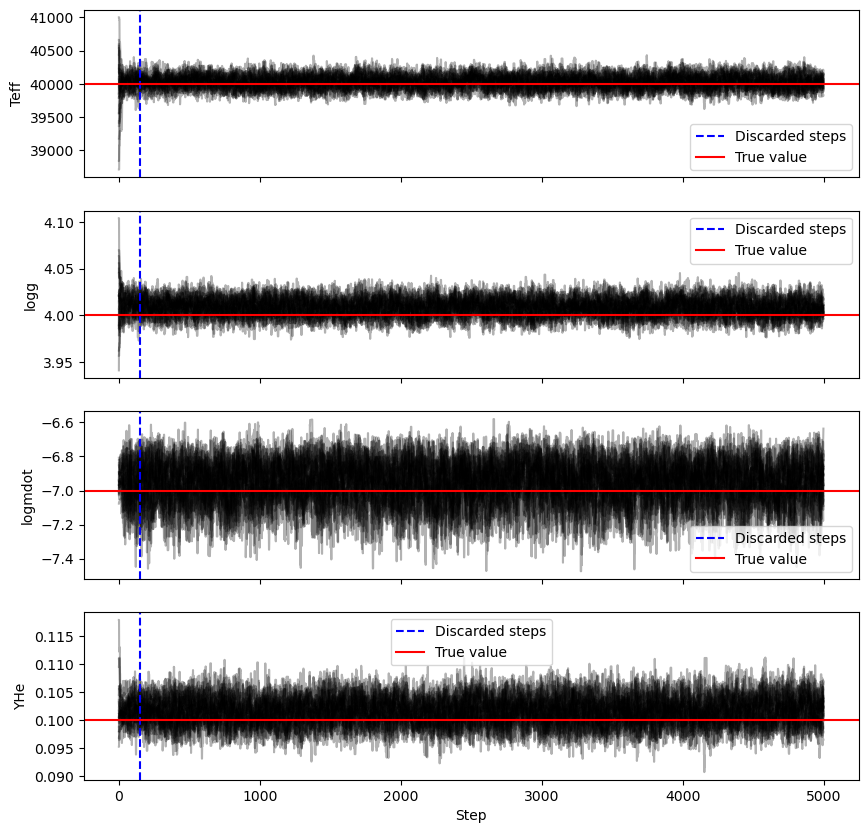

In [7]:
#results = load_results("mcmc_results_fixed_R_with_rot_broad.npz")
print('true:', results["theta_true"])
print('MAP:', results["theta_map"])
print_posterior_summary(results["flat_samples"])
plot_corner(results["flat_samples"], results["theta_true"])
plot_posterior_predictive(results,observed_flux,bloem_wl,model,snr=100,vsini=vsini,epsilon=epsilon,draw=False)
plot_chains(results["chain"], ndim=4, discard=results["discard"], truths=results["theta_true"])

# Now with rotational broadening

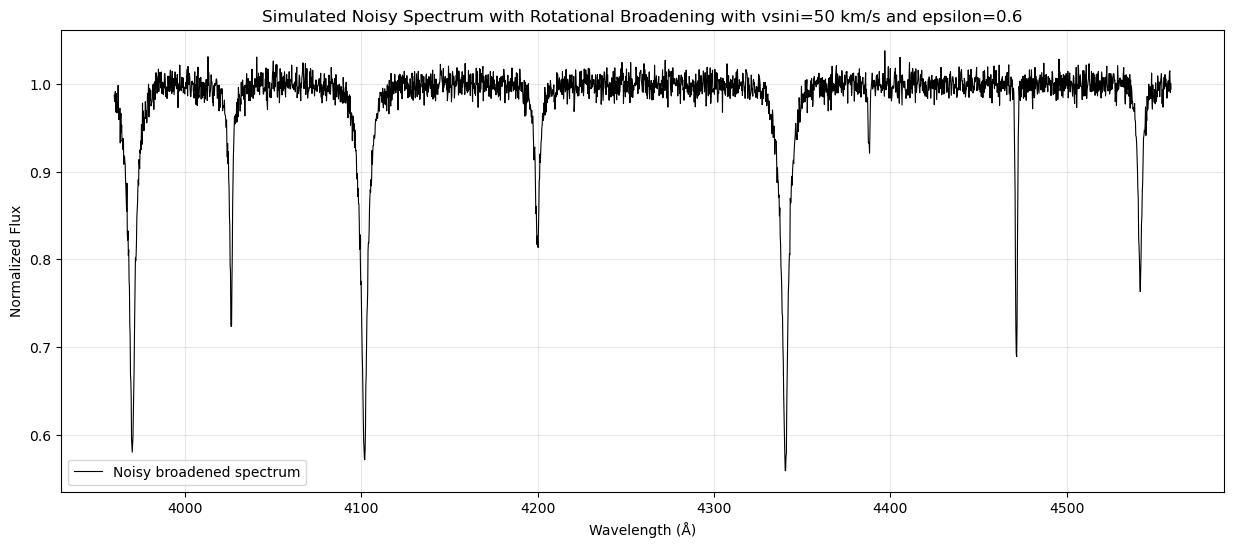

In [15]:
vsini = 50
epsilon = 0.6
observed_flux_broad = simulate_model_spectrum(theta_true_full,model=model,vsini=vsini,epsilon=epsilon,output_wl=bloem_wl)
observed_flux_broad = add_noise(observed_flux_broad, snr=100)

plt.figure(figsize=(15, 6))
plt.plot(bloem_wl, observed_flux_broad, color='black', label='Noisy broadened spectrum', lw=0.8)
plt.xlabel("Wavelength (Å)")
plt.ylabel("Normalized Flux")
plt.title(f"Simulated Noisy Spectrum with Rotational Broadening with vsini={vsini} km/s and epsilon={epsilon}")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [ ]:
theta_guess = [40000, 4, -7, 0.1]

results_broad = run_mcmc_fixed_radius(
    observed_flux=observed_flux_broad, 
    observed_wavelength=bloem_wl, 
    snr=100,
    first_guess_free=theta_guess,
    model=model,
    radius_fixed=radius_fixed,
    vsini=vsini,
    epsilon=epsilon,
    theta_true=theta_true,
    nwalkers=12,
    nsteps=500,
    )

print('true:', results_broad["theta_true"])
print('MAP:', results_broad["theta_map"])
print_posterior_summary(results_broad["flat_samples"])
plot_corner(results_broad["flat_samples"], results_broad["theta_true"])
plot_posterior_predictive(results_broad,observed_flux_broad,bloem_wl,model,snr=100,vsini=vsini,epsilon=epsilon,draw=False)
plot_chains(results_broad["chain"], ndim=4, discard=results_broad["discard"], truths=results_broad["theta_true"])

Evaluating log-posterior at theta_free: [ 4.e+04  4.e+00 -7.e+00  1.e-01]
Evaluating log-posterior at theta_free: [ 4.2e+04  4.0e+00 -7.0e+00  1.0e-01]
Evaluating log-posterior at theta_free: [ 4.0e+04  4.2e+00 -7.0e+00  1.0e-01]
Evaluating log-posterior at theta_free: [ 4.00e+04  4.00e+00 -7.35e+00  1.00e-01]
Evaluating log-posterior at theta_free: [ 4.00e+04  4.00e+00 -7.00e+00  1.05e-01]
Evaluating log-posterior at theta_free: [ 4.100e+04  3.800e+00 -7.175e+00  1.025e-01]
Evaluating log-posterior at theta_free: [ 4.02500e+04  4.10000e+00 -7.04375e+00  1.00625e-01]
Evaluating log-posterior at theta_free: [ 3.812500e+04  4.050000e+00 -7.196875e+00  1.028125e-01]
Evaluating log-posterior at theta_free: [ 4.10312500e+04  4.01250000e+00 -7.04921875e+00  1.00703125e-01]
Evaluating log-posterior at theta_free: [ 3.90937500e+04  4.03750000e+00 -7.14765625e+00  1.02109375e-01]
Evaluating log-posterior at theta_free: [ 4.05468750e+04  4.01875000e+00 -7.07382813e+00  1.01054688e-01]
Evaluating